# Recurrent neural networks

### The architecture for data where order carries the meaning

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The recurrence and why sharing weights across time is the same trick as sharing them across space, a vanilla RNN cell written by hand and checked against `nn.RNN`, backpropagation through time, the vanishing gradient measured rather than asserted, gradient clipping, and an hourly forecast where the RNN has to earn its place |
| **You should already know** | [The same network in PyTorch](../../07-neural-networks/03-the-same-net-in-pytorch/) · [Convolution and pooling](../../08-computer-vision/01-convolution-and-pooling/) helps but is not required |
| **Dataset** | UCI Bike Sharing, hourly hire counts (17,379 hours) |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [09-04 LSTM](../04-lstm/) |

---

## 1. The idea

A network that takes a fixed vector has nothing to say about order. Give it
twenty-four hours of bicycle hire counts as twenty-four columns and it learns
twenty-four separate coefficients. Permute those columns the same way in
training and in testing and it learns the permuted problem just as well, because
nothing in the architecture knows that column 23 happened one hour before the
thing we are predicting and column 0 happened a day before.

A recurrent layer knows. It reads one step at a time and carries a state:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

$h_t$ is what the network remembers after reading $t$ steps. It is a function of
the current input and of everything before it, reached through $h_{t-1}$. The
same $W_x$ and the same $W_h$ are used at every step: one matrix for reading the
input, one for carrying the state forward, and that is the entire architecture.

Reusing one matrix at every step is the same idea as a convolution. A
convolutional layer slides one small filter over every position in an image
because it assumes an edge is an edge wherever it turns up. A recurrent layer
applies one $W_x$ and one $W_h$ at every position in a sequence because it
assumes the rule for updating memory does not depend on what time it is. Both
assumptions buy the same two things: a parameter count that does not grow with
the length of the input, and a model you can run on an input longer than
anything it was trained on.

In [1]:
import sys
import math
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, running on {device}")

torch 2.11.0+cu128, running on cuda


The picture everyone draws is the network unrolled: the same cell copied once
per time step, with the state passed along the row. The copies are not separate
layers. They are one layer used repeatedly, which is why the arrows are all
labelled with the same two matrices.

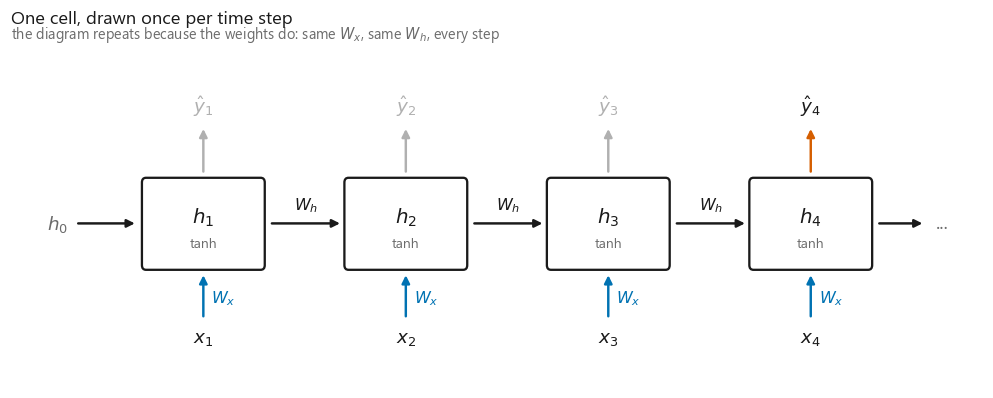

In [2]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11.4, 3.9))
STEP = 3.0

for t in range(4):
    left = t * STEP
    ax.add_patch(FancyBboxPatch((left, 0.75), 1.7, 1.05,
                                boxstyle="round,pad=0.06", linewidth=1.5,
                                edgecolor=style.INK, facecolor="white", zorder=3))
    ax.text(left + 0.85, 1.36, f"$h_{t + 1}$", ha="center", va="center",
            fontsize=13, color=style.INK, zorder=4)
    ax.text(left + 0.85, 1.02, "tanh", ha="center", va="center",
            fontsize=9, color=style.MUTED, zorder=4)

    # input into the cell
    ax.annotate("", xy=(left + 0.85, 0.66), xytext=(left + 0.85, 0.06),
                arrowprops=dict(arrowstyle="-|>", color=style.PALETTE[0], lw=1.6))
    ax.text(left + 0.85, -0.08, f"$x_{t + 1}$", ha="center", va="top",
            fontsize=12, color=style.INK)
    ax.text(left + 0.97, 0.34, "$W_x$", ha="left", va="center",
            fontsize=10.5, color=style.PALETTE[0])

    # output off the cell; only the last one is used by a forecaster
    used = t == 3
    ax.annotate("", xy=(left + 0.85, 2.52), xytext=(left + 0.85, 1.90),
                arrowprops=dict(arrowstyle="-|>", lw=1.6,
                                color=style.HIGHLIGHT if used else style.NEUTRAL))
    ax.text(left + 0.85, 2.62, f"$\\hat{{y}}_{t + 1}$", ha="center", va="bottom",
            fontsize=12, color=style.INK if used else style.NEUTRAL)

# the state travelling along the row, carried by one shared matrix
for t in range(3):
    left = t * STEP
    ax.annotate("", xy=(left + 2.92, 1.28), xytext=(left + 1.82, 1.28),
                arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=1.6))
    ax.text(left + 2.37, 1.40, "$W_h$", ha="center", va="bottom",
            fontsize=10.5, color=style.INK)

ax.annotate("", xy=(-0.12, 1.28), xytext=(-1.05, 1.28),
            arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=1.6))
ax.text(-1.15, 1.28, "$h_0$", ha="right", va="center", fontsize=12, color=style.MUTED)
ax.annotate("", xy=(11.55, 1.28), xytext=(10.82, 1.28),
            arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=1.6))
ax.text(11.7, 1.28, "...", ha="left", va="center", fontsize=13, color=style.MUTED)

ax.set_xlim(-2.0, 12.4)
ax.set_ylim(-0.8, 3.4)
ax.axis("off")
style.title(ax, "One cell, drawn once per time step",
            "the diagram repeats because the weights do: same $W_x$, same $W_h$, every step")
style.save(fig, FIG / "fig-01-unrolled.png")

The greyed arrows are outputs the model produces at every step but a forecaster
ignores. Reading twenty-four hours and predicting one number is a many-to-one
job, so only the last state reaches the output layer. Tagging every word in a
sentence would use all of them.

## 2. A cell from scratch, checked against nn.RNN

Three parameter tensors and one line of arithmetic. I write the loop over time
myself rather than reach for `nn.RNN`, because the loop is the part worth
seeing: everything difficult about this architecture happens inside it.

In [3]:
class RNNCellFromScratch(nn.Module):
    """One step of h_t = tanh(W_x x_t + W_h h_{t-1} + b)."""

    def __init__(self, n_in, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden
        # The same uniform init nn.RNN uses, so the comparison below is fair.
        bound = 1.0 / math.sqrt(n_hidden)
        self.W_x = nn.Parameter(torch.empty(n_hidden, n_in).uniform_(-bound, bound))
        self.W_h = nn.Parameter(torch.empty(n_hidden, n_hidden).uniform_(-bound, bound))
        self.b = nn.Parameter(torch.empty(n_hidden).uniform_(-bound, bound))

    def forward(self, x_t, h_prev):
        return torch.tanh(x_t @ self.W_x.T + h_prev @ self.W_h.T + self.b)


def unroll(cell, x, h0=None):
    """Run `cell` over the time axis of x, shaped (batch, time, features)."""
    batch, n_steps, _ = x.shape
    h = (torch.zeros(batch, cell.n_hidden, dtype=x.dtype, device=x.device)
         if h0 is None else h0)
    states = []
    for t in range(n_steps):        # this loop is the recurrent network
        h = cell(x[:, t], h)
        states.append(h)
    return torch.stack(states, dim=1), h

Nothing in `unroll` is cyclic. Once the loop has run, autograd holds an ordinary
feedforward graph `n_steps` layers deep in which every layer happens to use the
same weight matrix. That observation is the whole of the next section.

`nn.RNN` computes the same thing with two bias vectors instead of one, so
$b_{ih} + b_{hh}$ maps onto my single $b$. Copy the weights across and the two
should agree to floating-point noise.

In [4]:
n_in, n_hidden = 3, 16
torch.manual_seed(SEED)

reference = nn.RNN(input_size=n_in, hidden_size=n_hidden,
                   batch_first=True, nonlinearity="tanh")
mine = RNNCellFromScratch(n_in, n_hidden)

with torch.no_grad():
    mine.W_x.copy_(reference.weight_ih_l0)
    mine.W_h.copy_(reference.weight_hh_l0)
    mine.b.copy_(reference.bias_ih_l0 + reference.bias_hh_l0)

x_check = torch.randn(4, 12, n_in)
mine_states, mine_last = unroll(mine, x_check)
ref_states, ref_last = reference(x_check)

print(f"my states  {tuple(mine_states.shape)}   nn.RNN states  {tuple(ref_states.shape)}")
print(f"largest disagreement, all steps : {(mine_states - ref_states).abs().max():.3e}")
print(f"largest disagreement, last state: {(mine_last - ref_last[0]).abs().max():.3e}")
assert torch.allclose(mine_states, ref_states, atol=1e-6)
print("\nthe hand-written loop and nn.RNN agree")

my states  (4, 12, 16)   nn.RNN states  (4, 12, 16)
largest disagreement, all steps : 6.706e-08
largest disagreement, last state: 5.960e-08

the hand-written loop and nn.RNN agree


## 3. Backprop through time, and the gradient that does not arrive

Backpropagation through time is not a new algorithm. It is backpropagation on
the unrolled graph. The only thing to remember is that the same $W_h$ appears in
every layer, so its gradient is the sum of the contributions from all of them,
and autograd does that summing for free because gradients accumulate.

The cost is what makes it awkward. Memory grows with sequence length, since
every intermediate state has to be kept for the backward pass, and the steps
cannot be parallelised because step $t$ needs the output of step $t-1$. That
second point is the reason transformers exist.

The real problem is the chain rule itself. Differentiating the state at step $T$
with respect to the state at step 1 gives

$$\frac{\partial h_T}{\partial h_1} = \prod_{t=2}^{T} \operatorname{diag}\big(\tanh'(a_t)\big)\, W_h$$

where $a_t$ is the pre-activation. A product of $T-1$ matrices, and mostly the
same matrix. Products of matrices behave the way powers of a number behave: if
the typical factor has magnitude $c$, the product goes like $c^{T-1}$. Below one
it collapses towards zero, above one it runs away, and there is no value of
$W_h$ that keeps it near one in every direction at once, because one matrix has
to serve every direction.

That is the argument. Here it is as a measurement.

I build a fixed random RNN, feed it a random sequence, read one number off the
final state, and ask autograd for the gradient of that number with respect to
each input step. The gradient at step 1 is the size of the influence the first
input still has on the answer, what a long-range dependency would have to fight
through to be learned. I draw the entries of $W_h$ from a normal with standard
deviation $g/\sqrt{H}$, which puts the spectral radius near $g$, and sweep both
$g$ and the sequence length.

In [5]:
def step_gradient_norms(n_steps, gain, n_hidden=64, n_in=8, seed=0):
    """Gradient of a scalar read off h_T, measured at every input step."""
    gen = torch.Generator().manual_seed(seed)
    W_x = torch.randn(n_hidden, n_in, generator=gen) / math.sqrt(n_in)
    W_h = gain * torch.randn(n_hidden, n_hidden, generator=gen) / math.sqrt(n_hidden)
    readout = torch.randn(n_hidden, generator=gen) / math.sqrt(n_hidden)

    # Small inputs keep the state away from the flat ends of tanh at the start,
    # so what the sweep measures is the recurrence rather than saturation alone.
    x = (0.1 * torch.randn(1, n_steps, n_in, generator=gen)).requires_grad_(True)

    h = torch.zeros(1, n_hidden)
    for t in range(n_steps):
        h = torch.tanh(x[:, t] @ W_x.T + h @ W_h.T)
    (h @ readout).sum().backward()

    return x.grad[0].norm(dim=1).numpy()      # one norm per time step


LENGTHS = [2, 5, 10, 20, 30, 45, 60, 80, 100, 120]
GAINS = [0.6, 1.0, 1.6]
SEEDS = [0, 1, 2]

first_step = {}
for gain in GAINS:
    per_length = []
    for n_steps in LENGTHS:
        runs = [step_gradient_norms(n_steps, gain, seed=s)[0] for s in SEEDS]
        # Geometric mean: these numbers live on a log scale, so average there.
        per_length.append(float(np.exp(np.mean(np.log(runs)))))
    first_step[gain] = np.array(per_length)

profiles = {gain: step_gradient_norms(120, gain, seed=0) for gain in GAINS}


def per_step_factor(lengths, norms):
    """Least-squares slope of log(norm) against length, read as a rate per step."""
    L = np.asarray(lengths, dtype=float)
    y = np.log(np.asarray(norms))
    slope = ((L - L.mean()) * (y - y.mean())).sum() / ((L - L.mean()) ** 2).sum()
    return float(np.exp(slope))


for gain in GAINS:
    print(f"gain {gain:>3}  first-step gradient at T=2: {first_step[gain][0]:.3e}"
          f"   at T=120: {first_step[gain][-1]:.3e}"
          f"   measured factor per step: {per_step_factor(LENGTHS, first_step[gain]):.3f}")

C:\Users\pilot\AppData\Local\Temp\ipykernel_30576\1197947308.py:30: RuntimeWarning: divide by zero encountered in log
  per_length.append(float(np.exp(np.mean(np.log(runs)))))


gain 0.6  first-step gradient at T=2: 6.408e-01   at T=120: 0.000e+00   measured factor per step: nan
gain 1.0  first-step gradient at T=2: 1.060e+00   at T=120: 5.243e-03   measured factor per step: 0.956
gain 1.6  first-step gradient at T=2: 1.662e+00   at T=120: 3.806e+03   measured factor per step: 1.060


C:\Users\pilot\AppData\Local\Temp\ipykernel_30576\1197947308.py:39: RuntimeWarning: divide by zero encountered in log
  y = np.log(np.asarray(norms))
C:\Users\pilot\AppData\Local\Temp\ipykernel_30576\1197947308.py:40: RuntimeWarning: invalid value encountered in subtract
  slope = ((L - L.mean()) * (y - y.mean())).sum() / ((L - L.mean()) ** 2).sum()
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


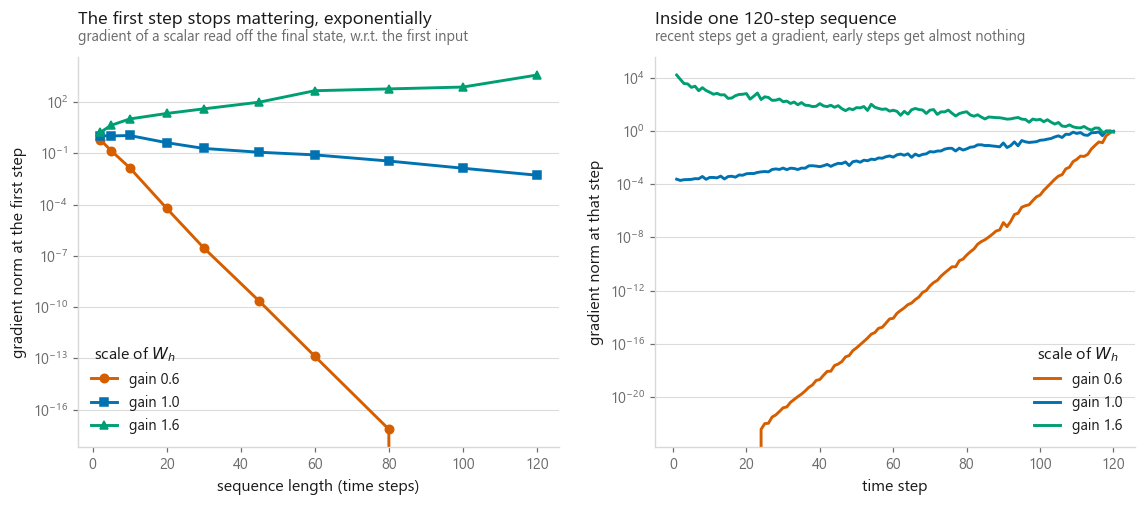

In [6]:
colours = [style.HIGHLIGHT, style.PALETTE[0], style.PALETTE[2]]
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))

for i, gain in enumerate(GAINS):
    axes[0].plot(LENGTHS, first_step[gain], marker=style.MARKERS[i],
                 color=colours[i], label=f"gain {gain}")
axes[0].set_yscale("log")
axes[0].set_xlabel("sequence length (time steps)")
axes[0].set_ylabel("gradient norm at the first step")
axes[0].legend(title="scale of $W_h$")
style.title(axes[0], "The first step stops mattering, exponentially",
            "gradient of a scalar read off the final state, w.r.t. the first input")

steps = np.arange(1, 121)
for i, gain in enumerate(GAINS):
    axes[1].plot(steps, profiles[gain], color=colours[i], label=f"gain {gain}")
axes[1].set_yscale("log")
axes[1].set_xlabel("time step")
axes[1].set_ylabel("gradient norm at that step")
axes[1].legend(title="scale of $W_h$")
style.title(axes[1], "Inside one 120-step sequence",
            "recent steps get a gradient, early steps get almost nothing")

style.save(fig, FIG / "fig-02-gradient-through-time.png")

Both panels are on a log scale, and a straight line on a log scale is an
exponential. The slope is the per-step factor printed above: a network whose
gradient shrinks by a fixed fraction each step has nothing left after a hundred
of them, in the literal sense that the number underflows towards zero.

Where a measured factor comes out gentler than the gain that produced it,
saturation is the reason. Once the state is large, $\tanh'$ is small, and it
multiplies into every term of the product and damps it.

This is why a vanilla RNN struggles with long-range structure. It is not that
the architecture cannot represent it: the same weights unrolled far enough can
carry a signal indefinitely. It is that gradient descent cannot find it, because
the gradient that would teach the network about step 1 arrives at machine zero.

### Clipping, which fixes exactly one half of this

The exploding half has a cheap fix. If the whole gradient vector is longer than
some threshold, rescale it to that length. The direction is untouched, so the
step still points downhill; only the size is capped.

In [7]:
torch.manual_seed(SEED)
steep = RNNCellFromScratch(1, 64)
with torch.no_grad():
    steep.W_h.copy_(1.6 * torch.randn(64, 64) / math.sqrt(64))

x_long = 0.1 * torch.randn(32, 60, 1)
_, h_last = unroll(steep, x_long)
h_last.pow(2).sum().backward()

params = list(steep.parameters())
flat_before = torch.cat([p.grad.flatten() for p in params]).clone()
total_before = nn.utils.clip_grad_norm_(params, max_norm=1.0)
flat_after = torch.cat([p.grad.flatten() for p in params])
cosine = (flat_before @ flat_after) / (flat_before.norm() * flat_after.norm())

print(f"gradient norm before clipping : {total_before:.2f}")
print(f"gradient norm after clipping  : {flat_after.norm():.2f}")
print(f"cosine between the two        : {cosine:.6f}")

gradient norm before clipping : 14326.79
gradient norm after clipping  : 1.00
cosine between the two        : 1.000000


The direction survives the clip, which is the property that makes it safe to
apply on every step whether or not it bites. One line, `nn.utils.clip_grad_norm_`,
and one long training run that ends in `nan` becomes one that does not.

Clipping does nothing for the vanishing half. You cannot rescale a gradient back
into existence once the product has flattened it. That takes a different
recurrence, with a path through time that does not pass through a matrix
multiply and a squashing function every step, which is the [LSTM](../04-lstm/).

## 4. Forecasting bicycle hire

17,379 hourly counts of bicycles hired in Washington DC across 2011 and 2012.
The task: given the last twenty-four hours, predict the next one.

In [8]:
X_bike, hires = datasets.bike_sharing()
counts = hires.to_numpy().astype(np.float32)

WINDOW = 24
n_windows = len(counts) - WINDOW
starts = np.arange(n_windows)
windows = counts[starts[:, None] + np.arange(WINDOW)[None, :]]   # (n, 24) history
targets = counts[starts + WINDOW]                                # (n,) next hour
hours = X_bike["hr"].to_numpy()[starts + WINDOW]                 # hour of the target

n_train = int(0.8 * n_windows)
print(f"{len(counts):,} hourly observations -> {n_windows:,} windows of {WINDOW} hours")
print(f"train: first {n_train:,} windows    test: last {n_windows - n_train:,} windows")
print(f"hires per hour, min {counts.min():.0f}, mean {counts.mean():.1f}, max {counts.max():.0f}")

17,379 hourly observations -> 17,355 windows of 24 hours
train: first 13,884 windows    test: last 3,471 windows
hires per hour, min 1, mean 189.5, max 977


**The split is by time, and it has to be.** A random split would put the hour
before and the hour after a test hour into the training set. Neighbouring
windows share twenty-three of their twenty-four values, so the model would be
scored on windows it had almost memorised, and the score would be far better
than anything you would see in use. The question we actually want answered is
whether the model can predict an hour that has not happened yet, so the test set
is the last stretch of the calendar and nothing from it is available during
training. The boundary windows still reach back a day into the training period,
which is fine: that history is genuinely available at prediction time. What
never crosses the line is a target.

Scaling follows the same discipline. The mean and standard deviation come from
the training hours only. Computing them over the whole series would leak the
scale of a future summer into the model.

In [9]:
mu = float(windows[:n_train].mean())
sigma = float(windows[:n_train].std())


def scale(a):
    return (a - mu) / sigma


def unscale(a):
    return a * sigma + mu


def rmse(pred, true):
    return float(np.sqrt(np.mean((np.asarray(pred) - np.asarray(true)) ** 2)))


y_test = targets[n_train:]
print(f"training mean {mu:.2f} hires, training sd {sigma:.2f} hires")

training mean 174.72 hires, training sd 166.92 hires


Two things to beat before an RNN is worth anything. The first is persistence:
predict that the next hour equals the last one. The second exploits the daily
cycle: predict that the next hour equals the same hour yesterday, which is the
first value in the window. Neither has any parameters.

Then a linear model on the flattened window: twenty-four lags, twenty-five
coefficients. This is the honest competitor. It sees exactly the same numbers
the RNN sees, in the same order, and it can learn any fixed weighting of them.

In [10]:
from sklearn.linear_model import LinearRegression

pred_last = windows[n_train:, -1]         # the previous hour
pred_yesterday = windows[n_train:, 0]     # the same hour a day earlier

linear = LinearRegression().fit(scale(windows[:n_train]), scale(targets[:n_train]))
pred_linear = unscale(linear.predict(scale(windows[n_train:])))

rmse_last = rmse(pred_last, y_test)
rmse_yesterday = rmse(pred_yesterday, y_test)
rmse_linear = rmse(pred_linear, y_test)

print(f"last value        RMSE {rmse_last:7.2f} hires")
print(f"same hour, -24h   RMSE {rmse_yesterday:7.2f} hires")
print(f"linear, 24 lags   RMSE {rmse_linear:7.2f} hires")

last value        RMSE  129.72 hires
same hour, -24h   RMSE  134.85 hires
linear, 24 lags   RMSE   81.77 hires


Now the RNN. Section 2 established that my loop and `nn.RNN` compute the same
function, so from here I use the library version: it fuses the loop into one
kernel and is several times faster, which matters when the loop runs
twenty-four times per batch.

One hidden layer, forty-eight units, and only the final state reaches the output
layer, the many-to-one shape from the diagram.

In [11]:
from torch.utils.data import TensorDataset, DataLoader


class Forecaster(nn.Module):
    """24 hours in, one hour out. The last state is the summary of the window."""

    def __init__(self, n_hidden=48):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=n_hidden,
                          batch_first=True, nonlinearity="tanh")
        self.head = nn.Linear(n_hidden, 1)

    def forward(self, x):
        states, _ = self.rnn(x)               # (batch, time, hidden)
        return self.head(states[:, -1]).squeeze(-1)


def as_sequence(a):
    """(n, 24) of counts -> (n, 24, 1) scaled tensor with an explicit feature axis."""
    return torch.tensor(scale(a), dtype=torch.float32).unsqueeze(-1)


X_train_t = as_sequence(windows[:n_train]).to(device)
X_test_t = as_sequence(windows[n_train:]).to(device)
y_train_t = torch.tensor(scale(targets[:n_train]), dtype=torch.float32).to(device)
y_test_t = torch.tensor(scale(targets[n_train:]), dtype=torch.float32).to(device)

print(f"training tensor {tuple(X_train_t.shape)}, test tensor {tuple(X_test_t.shape)}")

training tensor (13884, 24, 1), test tensor (3471, 24, 1)

In [12]:
def train(model, X_tr, y_tr, X_te, y_te, epochs=18, lr=3e-3, batch_size=128, clip=1.0):
    """The loop from the PyTorch notebook, with clipping added between 3 and 4."""
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    loss_fn = nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_rmse": [], "test_rmse": [], "grad_norm": []}

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            optimiser.zero_grad()                                   # 1
            loss = loss_fn(model(xb), yb)                           # 2
            loss.backward()                                         # 3
            total = nn.utils.clip_grad_norm_(model.parameters(), clip)
            history["grad_norm"].append(float(total))
            optimiser.step()                                        # 4

        model.eval()
        with torch.no_grad():
            # RMSE reported in hires, not in standard deviations, so it can be
            # compared against the baselines directly.
            history["train_rmse"].append(sigma * float(((model(X_tr) - y_tr) ** 2).mean().sqrt()))
            history["test_rmse"].append(sigma * float(((model(X_te) - y_te) ** 2).mean().sqrt()))
    return history


torch.manual_seed(SEED)
rnn = Forecaster().to(device)
print(f"trainable parameters: {sum(p.numel() for p in rnn.parameters()):,}")

history = train(rnn, X_train_t, y_train_t, X_test_t, y_test_t)

with torch.no_grad():
    pred_rnn = unscale(rnn(X_test_t).cpu().numpy())
rmse_rnn = rmse(pred_rnn, y_test)

clipped = sum(g > 1.0 for g in history["grad_norm"])
print(f"\nfinal training RMSE {history['train_rmse'][-1]:.2f} hires")
print(f"final test RMSE     {rmse_rnn:.2f} hires")
print(f"steps where the gradient hit the clip: {clipped:,} of {len(history['grad_norm']):,}")

trainable parameters: 2,497



final training RMSE 37.69 hires
final test RMSE     51.91 hires
steps where the gradient hit the clip: 99 of 1,962


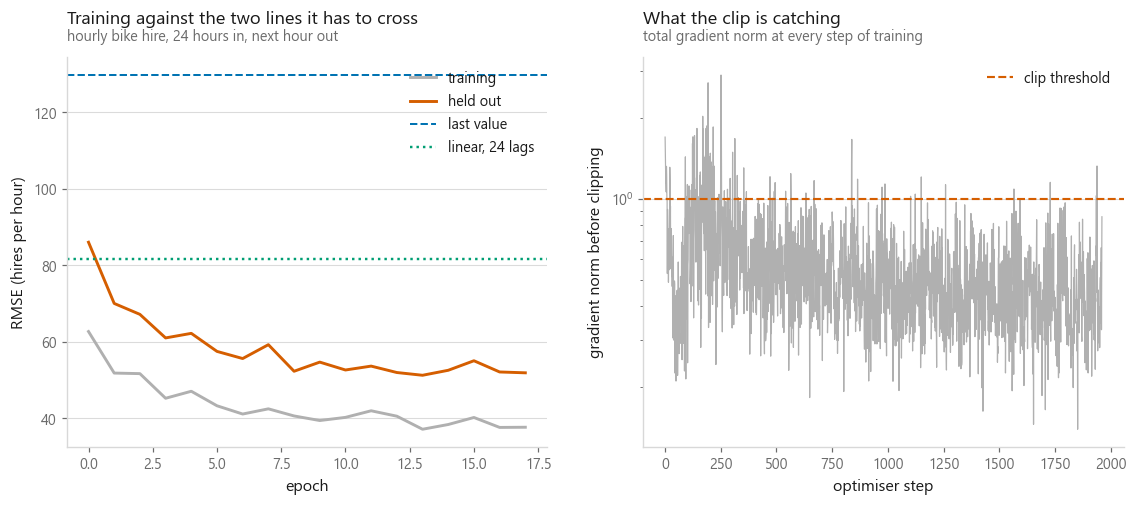

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))

axes[0].plot(history["train_rmse"], color=style.NEUTRAL, label="training")
axes[0].plot(history["test_rmse"], color=style.HIGHLIGHT, label="held out")
axes[0].axhline(rmse_last, color=style.PALETTE[0], linestyle="--", linewidth=1.3,
                label="last value")
axes[0].axhline(rmse_linear, color=style.PALETTE[2], linestyle=":", linewidth=1.6,
                label="linear, 24 lags")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("RMSE (hires per hour)")
axes[0].legend()
style.title(axes[0], "Training against the two lines it has to cross",
            "hourly bike hire, 24 hours in, next hour out")

axes[1].plot(history["grad_norm"], color=style.NEUTRAL, linewidth=0.8)
axes[1].axhline(1.0, color=style.HIGHLIGHT, linestyle="--", linewidth=1.4,
                label="clip threshold")
axes[1].set_yscale("log")
axes[1].set_xlabel("optimiser step")
axes[1].set_ylabel("gradient norm before clipping")
axes[1].legend()
style.title(axes[1], "What the clip is catching",
            "total gradient norm at every step of training")

style.save(fig, FIG / "fig-03-training.png")

In [14]:
scores = pd.DataFrame([
    {"model": "last value", "parameters": 0, "test RMSE (hires)": rmse_last},
    {"model": "same hour yesterday", "parameters": 0, "test RMSE (hires)": rmse_yesterday},
    {"model": "linear on 24 lags", "parameters": WINDOW + 1, "test RMSE (hires)": rmse_linear},
    {"model": "RNN, 48 hidden", "parameters": sum(p.numel() for p in rnn.parameters()),
     "test RMSE (hires)": rmse_rnn},
]).sort_values("test RMSE (hires)").reset_index(drop=True)

print(scores.round(2).to_string(index=False))
print(f"\nbest on the held-out period: {scores.loc[0, 'model']}")
print(f"RNN against the linear model: {100 * (rmse_linear - rmse_rnn) / rmse_linear:+.1f}% RMSE")
print(f"RNN against persistence     : {100 * (rmse_last - rmse_rnn) / rmse_last:+.1f}% RMSE")

              model  parameters  test RMSE (hires)
     RNN, 48 hidden        2497              51.91
  linear on 24 lags          25              81.77
         last value           0             129.72
same hour yesterday           0             134.85

best on the held-out period: RNN, 48 hidden
RNN against the linear model: +36.5% RMSE
RNN against persistence     : +60.0% RMSE


## 5. Where it wins, and where a linear model is enough

The table above is the result, and I am not going to dress it up. I did not
assume the RNN would come first, and on a one-hour horizon there is a good
reason it might not: the next hour is close to a fixed weighted average of the
last few, and a fixed weighted average is precisely what a linear model on
twenty-four lags is. The RNN can express that too, along with a great deal more,
but the extra capacity has to pay for itself against a competitor that is
already sitting on the right functional form.

The average hides where the errors live. Bike hire is not equally hard at every
hour of the day: the small hours barely move, the evening commute is a spike,
and the same percentage error costs very different numbers of bicycles.

 hour  last value  linear   RNN
    0        55.0    69.1  31.8
    1        36.0    41.5  26.1
    2        22.9    43.5  23.2
    3        24.1    34.6  23.2
    4        14.5    24.1  15.1
    5        25.9    20.4  20.7
    6        88.8    49.8  27.0
    7       226.7   135.9  62.7
    8       228.1   159.8 117.1
    9       295.1   193.3  53.6
   10       141.2    55.9  42.4
   11        69.5    68.9  51.6
   12        77.0    71.5  57.3
   13        42.0    69.3  48.9
   14        38.2    56.6  36.8
   15        51.6    66.4  46.3
   16       125.3    83.0  63.3
   17       267.2   123.0  88.1
   18        88.5    72.6  65.8
   19       186.1    65.2  65.6
   20       129.1    52.4  44.8
   21        90.2    51.9  38.9
   22        65.0    41.7  35.3
   23        60.0    44.4  33.4

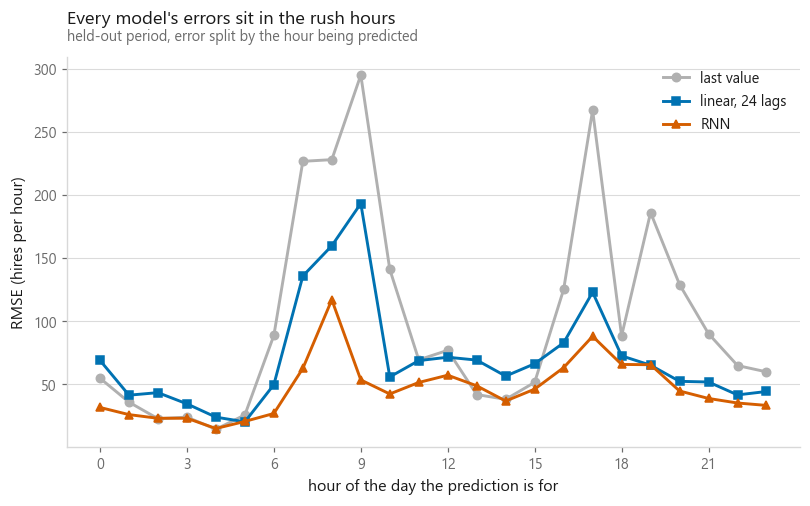

In [15]:
test_hours = hours[n_train:]
by_hour = pd.DataFrame({
    "hour": np.arange(24),
    "last value": [rmse(pred_last[test_hours == h], y_test[test_hours == h]) for h in range(24)],
    "linear": [rmse(pred_linear[test_hours == h], y_test[test_hours == h]) for h in range(24)],
    "RNN": [rmse(pred_rnn[test_hours == h], y_test[test_hours == h]) for h in range(24)],
})

fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.plot(by_hour["hour"], by_hour["last value"], color=style.NEUTRAL,
        marker=style.MARKERS[0], label="last value")
ax.plot(by_hour["hour"], by_hour["linear"], color=style.PALETTE[0],
        marker=style.MARKERS[1], label="linear, 24 lags")
ax.plot(by_hour["hour"], by_hour["RNN"], color=style.HIGHLIGHT,
        marker=style.MARKERS[2], label="RNN")
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hour of the day the prediction is for")
ax.set_ylabel("RMSE (hires per hour)")
ax.legend()
style.title(ax, "Every model's errors sit in the rush hours",
            "held-out period, error split by the hour being predicted")
style.save(fig, FIG / "fig-04-error-by-hour.png")

print(by_hour.round(1).to_string(index=False))

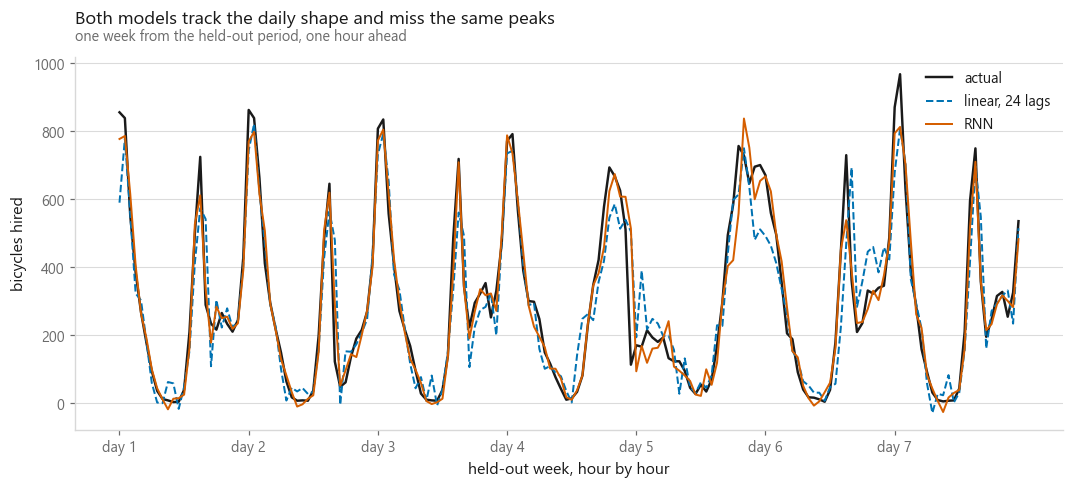

In [16]:
week = np.arange(24 * 7 * 4, 24 * 7 * 5)      # one week from the middle of the test set

fig, ax = plt.subplots(figsize=(11.6, 4.4))
ax.plot(np.arange(len(week)), y_test[week], color=style.INK, linewidth=1.6, label="actual")
ax.plot(np.arange(len(week)), pred_linear[week], color=style.PALETTE[0],
        linewidth=1.3, linestyle="--", label="linear, 24 lags")
ax.plot(np.arange(len(week)), pred_rnn[week], color=style.HIGHLIGHT,
        linewidth=1.3, label="RNN")
ax.set_xticks(np.arange(0, len(week), 24))
ax.set_xticklabels([f"day {d + 1}" for d in range(len(week) // 24)])
ax.set_xlabel("held-out week, hour by hour")
ax.set_ylabel("bicycles hired")
ax.legend()
style.title(ax, "Both models track the daily shape and miss the same peaks",
            "one week from the held-out period, one hour ahead")
style.save(fig, FIG / "fig-05-forecast-week.png")

The week chart says more than the RMSE column. Both models follow the two
commuter peaks and the overnight trough without being told that days exist, and
both shave the tops off the sharpest spikes, because a squared-error loss is
happier being slightly low on a peak than badly wrong on either side of it.
Their errors are correlated, which is the tell that they are using the same
information in nearly the same way.

So when is a recurrent layer worth the trouble? When the useful history is
longer than you can comfortably flatten, when the sequences have different
lengths, or when what matters is a pattern rather than a fixed lag: "sales rose
for three consecutive weeks" is a thing a state can carry and a fixed lag
weighting cannot express. A one-hour horizon on a strongly periodic series with
twenty-four inputs is none of those. It is the case where a linear model on the
lags is a serious opponent, and the point of running it first is to find out.

The other honest note: I gave the model the counts alone. The dataset also
carries temperature, humidity, holiday flags, and the hour of the day, which is
what the tabular chapters feed their models. This notebook is about the
architecture, so it uses the sequence and nothing else.

## Cheat sheet

| | |
|---|---|
| **The recurrence** | `h = tanh(x_t @ W_x.T + h @ W_h.T + b)` in a loop. One $W_x$ and one $W_h$ for every step |
| **Weight sharing** | Across time, the same idea as a convolution across space. Parameter count does not grow with input length |
| **Shapes** | `nn.RNN(batch_first=True)` takes `(batch, time, features)` and returns `(output, h_n)` with `h_n` shaped `(layers, batch, hidden)` |
| **BPTT** | Nothing special. Unroll, call `backward()`. Memory grows with sequence length and the steps cannot be parallelised |
| **Vanishing** | The gradient through $T$ steps carries a product of $T$ Jacobians. Under one it dies, over one it runs away |
| **Clipping** | `nn.utils.clip_grad_norm_(model.parameters(), 1.0)`. Fixes exploding only, and keeps the direction |
| **Time series splits** | Split by time, never at random. Overlapping windows make a random split close to training on the test set |
| **Scaling** | Statistics from the training portion only |
| **Always** | Run persistence first. A model that cannot beat "same as last hour" has not learned anything |

## What to remember

1. A recurrent layer carries a state and applies the same two matrices at every
   step. That is weight sharing across time, and it is the convolution
   argument moved from space to sequence.
2. The loop over time is the architecture. Write it once by hand and `nn.RNN`
   stops being mysterious.
3. Backpropagation through time is ordinary backpropagation on the unrolled
   graph. The unrolled graph is deep, which is the whole problem.
4. The gradient reaching the first time step falls off exponentially with
   sequence length. It is measurable in ten lines, and the measurement is more
   convincing than the derivation.
5. Clipping fixes exploding gradients and does nothing at all for vanishing
   ones. Vanishing needs a different recurrence.
6. On a short horizon over a periodic series, a linear model on the lags is hard
   to beat. Run the baselines before you decide the architecture was the answer.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [09-04 LSTM](../04-lstm/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#RNN` `#PyTorch` `#TimeSeries` `#Forecasting`
`#MachineLearning` `#Python` `#MLTutorial` `#LearnMachineLearning` `#AI`